#### Gaussian random path sampling in `Cabinet` environment

In [1]:
%run ../../package/init_scripts/init_dev_env.py
from package.panda_env import * 

Initializing development environment with [9] scripts

[0/9] Calling [init_ipython_setup.py]
Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.

[1/9] Calling [init_utility.py]
[utility] package initialized.
 from utils import *
 from viz import *
 from filters import *

[2/9] Calling [init_kinematics.py]
[kinematics] package initialized.
 from transforms import *
 from numpy_chain import *

[3/9] Calling [init_mujoco_sim.py]
[mujoco_sim] package initialized.
 mujoco version: (3, 4, 0)
 from parser import *
 from mujoco_utils import *
 from mujoco_draw import *
 from mujoco_ik import *

[4/9] Calling [init_qt.py]
[qt] package initialized.

[5/9] Calling [init_gaussian_process.py]
[gaussian_process] package initialized.
 from kernels import *
 from gp_utils import *

[6/9] Calling [init_mocap.py]
[m

In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files=[
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/cabinet/cabinet_half_closed.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_cabinet_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [4] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/cabinet/cabinet_half_closed.xml]
  - [3] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_cabinet_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[28]
 [0/28] [world] parent:[world] mass:[0.00]kg
 [1/28] [panda_base] parent:[world] mass:[0.00]kg
 [2/28] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/28] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/28] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/28] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/28] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/28] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/28] [panda_link_6] parent:[panda_link_5] mass:[1.50]

#### 1. Get `Cabinet` scene + interpolate the initial and final poses

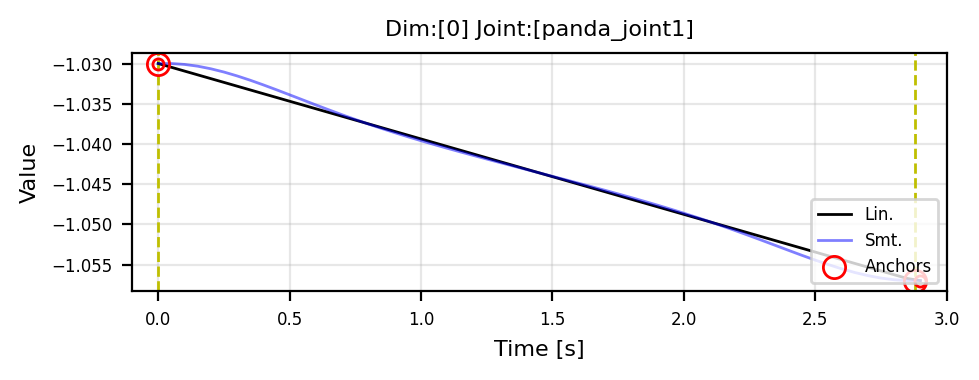

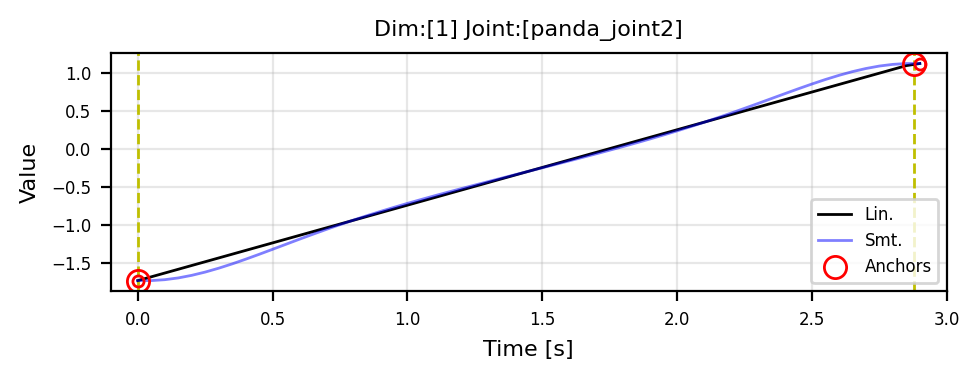

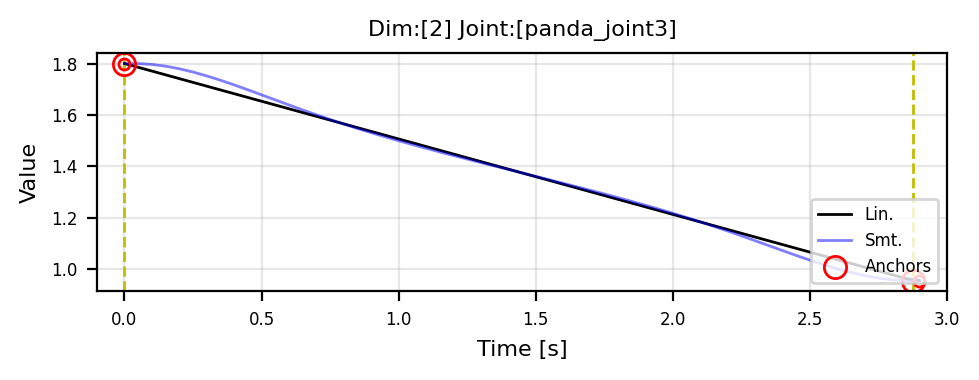

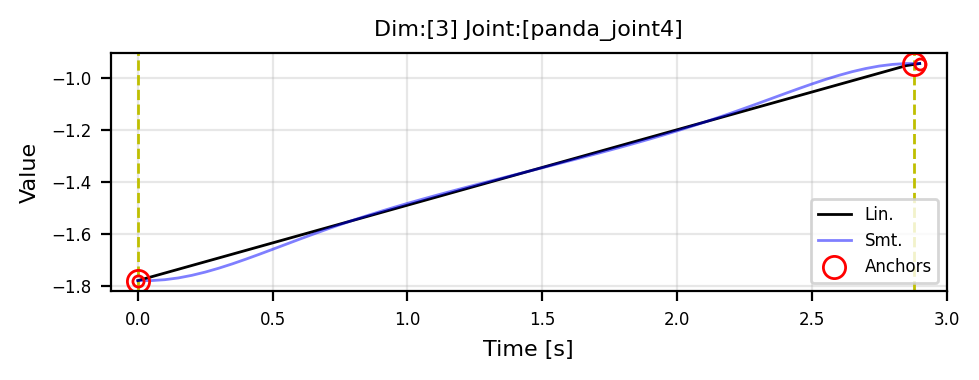

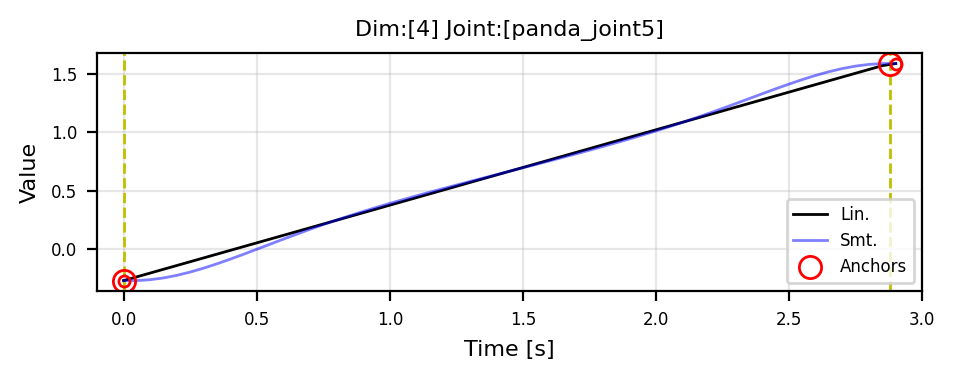

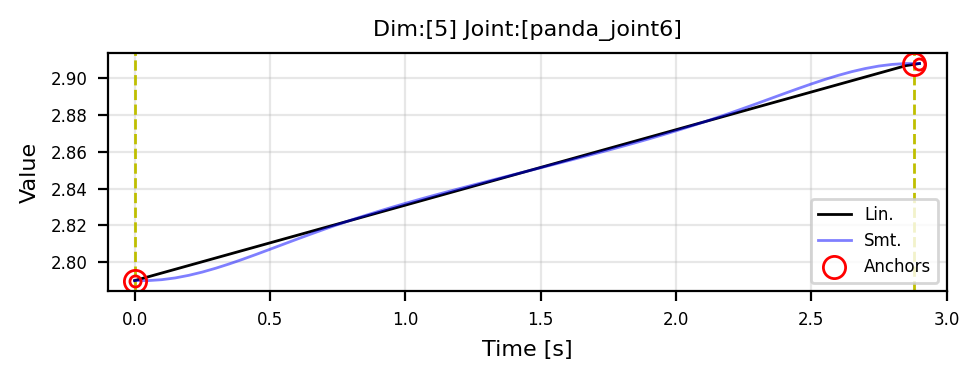

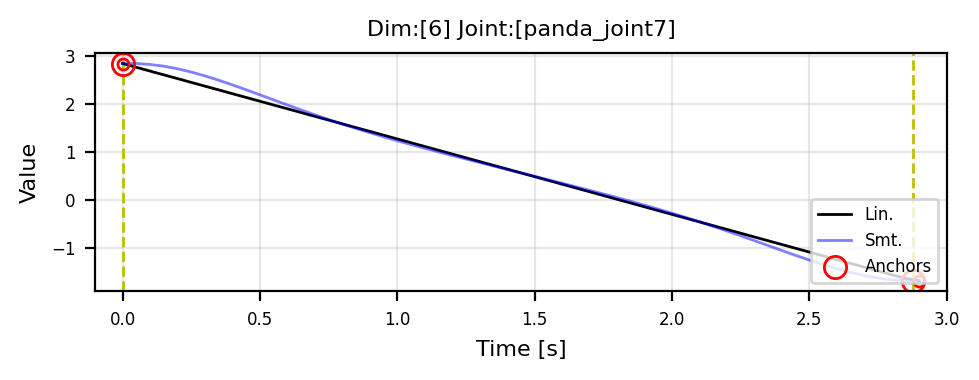

Done.


In [3]:
# Configurations
panda_joints          = get_panda_joint_names()
inspire_joints        = get_inspire_joint_names()
inspire_active_joints = env.get_active_among_joints(inspire_joints)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
qactive_inspire0      = get_qactive_inspire()
q_inspire0            = get_q_inspire(env)
q_pandas              = get_q_pandas_cabinet()

# Compute piecewise linear trajectories from init to final
anchors = np.vstack((q_pandas['init'],q_pandas['final'])) # (M x dim)
n_anchor,dim = anchors.shape[0],anchors.shape[1]
res = get_interp_const_vel_traj_nd(
    anchors = anchors, # (M x dim)
    vel     = 90*D2R, # maximum velocity
    Hz      = 20,
)
times        = res['times_interp'] # (L)
trajs_lin    = res['anchors_interp'] # (L x dim)
times_anchor = res['times_anchor'] # (M,)
idxs_anchor  = res['idxs_anchor'] # (M,)
L,t_max = times.shape[0],times[1]

# Shape joint trajectory
trajs_smt = np.zeros_like(trajs_lin) # (L x dim)
for d_idx in range(dim):
    res = traj_1d_shaper(
        t        = times, # (L,)
        x_ref    = trajs_lin[:,d_idx], # (L)
        idxs_eq  = idxs_anchor, # (M,)
        vals_eq  = anchors[:,d_idx], #(M,)
        v_init   = 0.0,
        v_final  = 0.0,
        lambda_j = 1e-4,
    )
    trajs_smt[:,d_idx] = res['z'] # (L,)

# Plot interpolated trajectries
for d_idx in range(dim):
    plt.figure(figsize=(5,2))
    for k in range(n_anchor):
        plt.axvline(times_anchor[k],color='y',ls='--',lw=1.0)
    plt.plot(times,trajs_lin[:,d_idx],'-',color='k',lw=1.0,label="Lin.")
    plt.plot(times,trajs_smt[:,d_idx],'-',color='b',alpha=0.5,lw=1.0,label="Smt.")
    kwargs = {'linestyle':'none','marker':'o','mfc':'none','mec':'r','mew':1}
    plt.plot(times_anchor,anchors[:,d_idx],ms=8,label='Anchors',**kwargs)
    plt.plot(times[idxs_anchor],trajs_lin[idxs_anchor,d_idx],ms=4,**kwargs)
    plt.xlabel("Time [s]",fontsize=8); plt.ylabel("Value",fontsize=8)
    plt.title("Dim:[%d] Joint:[%s]"%(d_idx,panda_joints[d_idx]),fontsize=8)
    plt.xlim([times[0]-0.1,times[-1]+0.1])
    plt.grid(True,alpha=0.3); plt.legend(loc='lower right',fontsize=6)
    plt.tight_layout(); plt.show()
print ("Done.")

#### 2. Prepare GRP sampling + test run

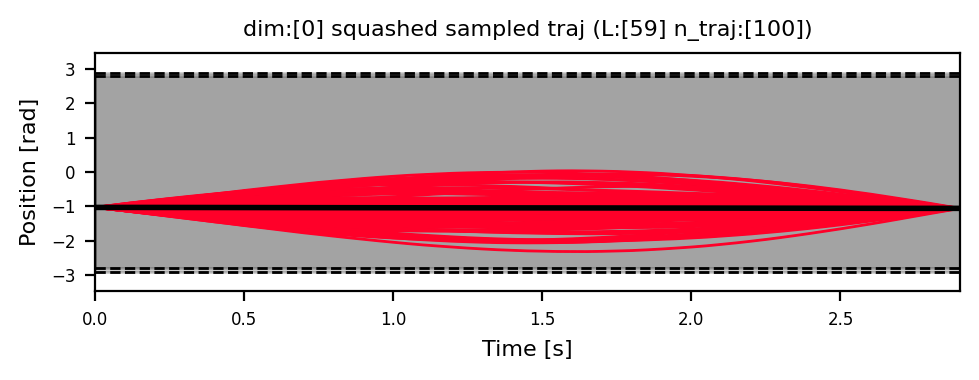

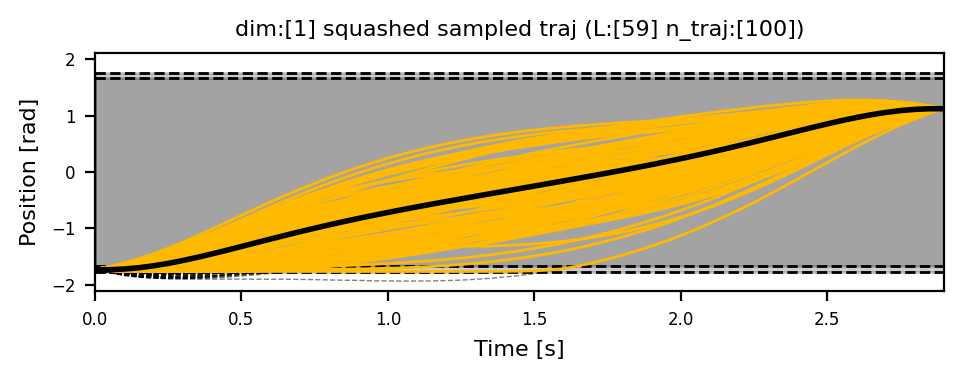

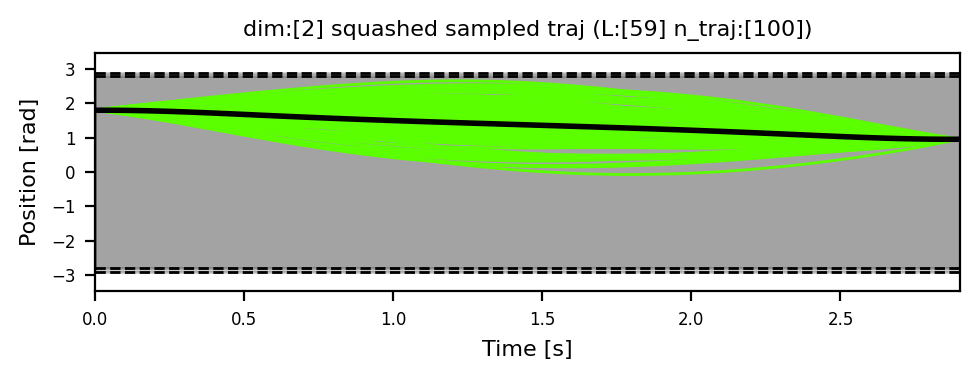

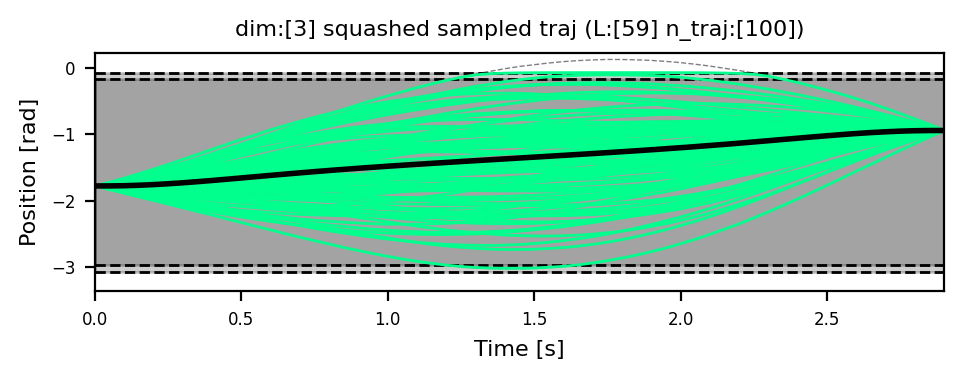

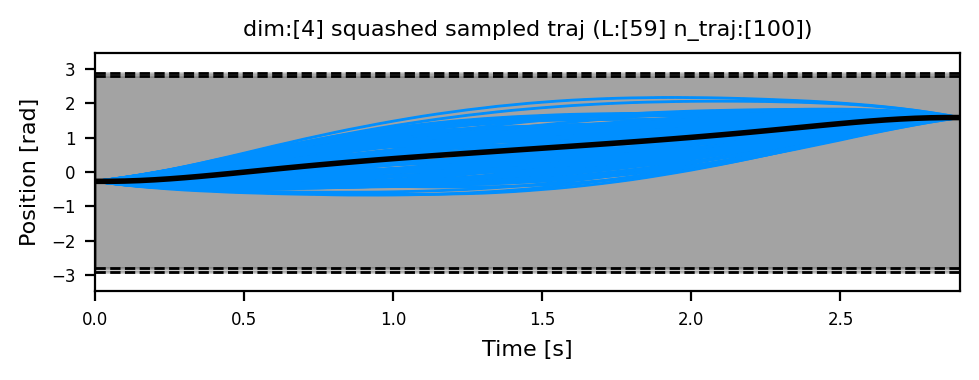

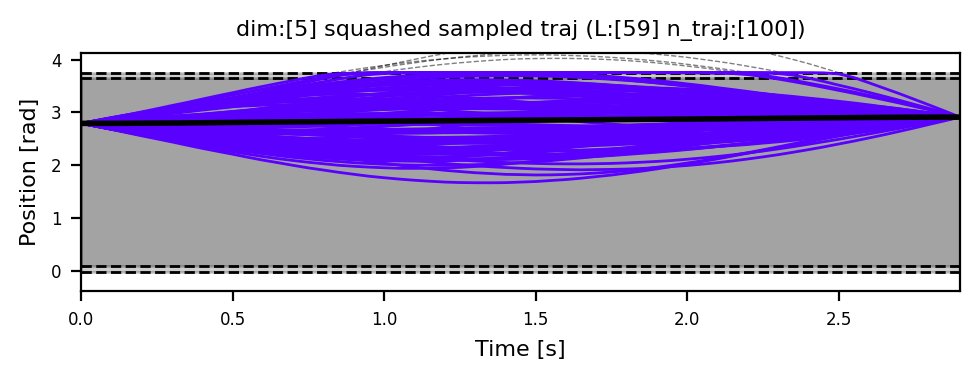

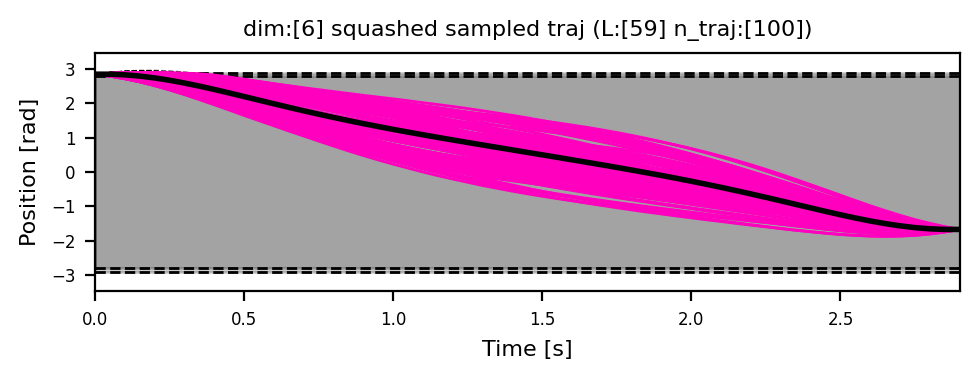

In [4]:
# Define (mean-zero) Hilbert space
t_max  = times[-1]
t_in   = np.array([0,t_max])
t_out  = np.linspace(0.0,t_max,L)
hyp    = {'length_scale':0.5*t_max,'variance':1.0}
K_chol = get_schur_K_chol(t_in,t_out,rbf_kernel,hyp)

# Sample from the mean-zero (ms) Hilbert space and mean shift (ms)
n_traj   = 100 # number of trajectories
trajs_mz = sample_trajs_multidim(
    K_chol      = K_chol,
    n_traj      = n_traj,
    d           = dim,
    use_uniform = True,
) # (L x n_traj x dim)
trajs_ms = trajs_mz + trajs_smt[:,None,:] # (L x n_traj x dim)

# Soft squash (sq)
x_mins = env.get_joint_mins(panda_joints)
x_maxs = env.get_joint_maxs(panda_joints)
m      = 0.1 # soft squash margin
trajs_sq = soft_squash_multidim(
    trajs_ms,x_min=x_mins,x_max=x_maxs,margin=m,dim_axis=2,
) # (L x n_traj x dim)

# Plot sampled trajctories
colors = get_colors(n_color=dim,cmap_name='gist_rainbow')
for d_idx in range(dim): # for each dim
    plt.figure(figsize=(5,2))
    traj_ms  = trajs_ms[:,:,d_idx] # (L,n_traj)
    traj_sq  = trajs_sq[:,:,d_idx] # (L,n_traj)
    traj_smt = trajs_smt[:,d_idx]  # (L,)
    rgba     = colors[d_idx]
    plt.fill_between(t_out,x_mins[d_idx],x_maxs[d_idx],color='k',alpha=0.2)
    plt.fill_between(t_out,x_mins[d_idx]+m,x_maxs[d_idx]-m,color='k',alpha=0.2)
    plt.plot(t_out,np.full_like(t_out,x_mins[d_idx]+m),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_maxs[d_idx]-m),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_mins[d_idx]),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_maxs[d_idx]),'--',lw=1.0,color='k')
    plt.plot(t_out,traj_ms,'--',color='k',lw=0.5,alpha=0.5)
    plt.plot(t_out,traj_sq,'-',color=rgba,lw=1.0,alpha=1.0)
    plt.plot(t_out,traj_smt,'-',color='k',lw=2.0,alpha=1.0)
    plt.xlabel('Time [s]',fontsize=8); plt.ylabel('Position [rad]',fontsize=8);
    plt.xlim([0.0,t_out[-1]])
    plt.ylim([x_mins[d_idx]-0.1*(x_maxs[d_idx]-x_mins[d_idx]),
              x_maxs[d_idx]+0.1*(x_maxs[d_idx]-x_mins[d_idx])])
    plt.title("dim:[%d] squashed sampled traj (L:[%d] n_traj:[%d])"%
              (d_idx,L,n_traj),fontsize=8)
    plt.tight_layout(); plt.show()

#### 3. Animate the initial interpolated (`trajs_smt`) trajectories

2026-03-12 22:03:07.726 python[12591:2227189] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


Final RGB image captured.


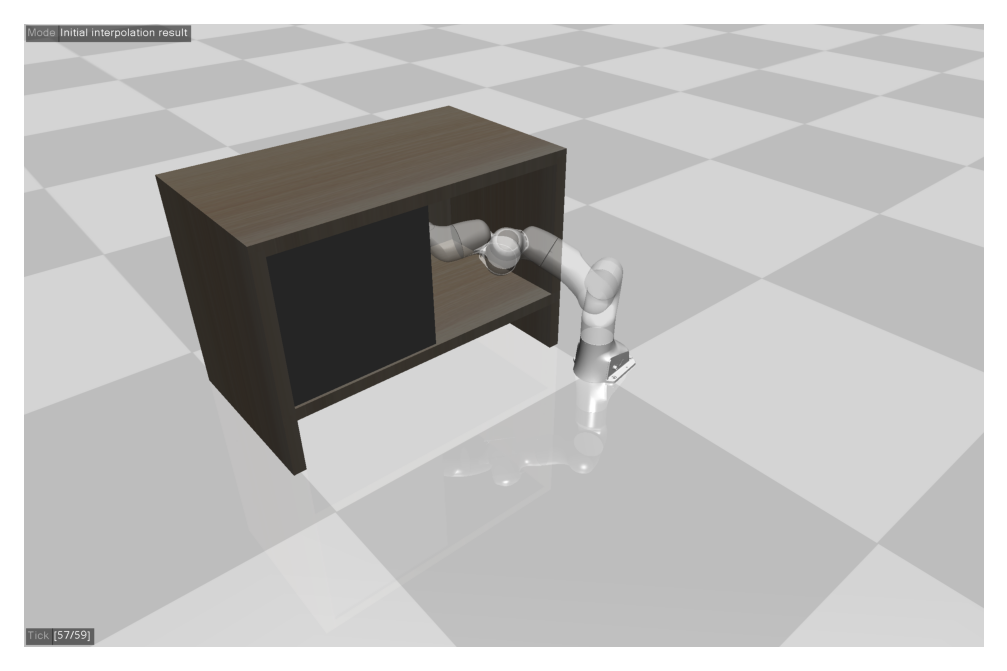

Done.


In [5]:
mode_str = "Initial interpolation result"
animate_cabinet_env_traj(
    env,
    mode_str,
    trajs_smt,
    panda_joints,
    inspire_joints,
    q_pandas,
    q_inspire0,
    p_cylinder_offset0,
)
imshow(env.final_rgb_img)
print ("Done.")

#### 4. Sample and select the best joint trajectory

In [6]:
# Initialize env and viewer
set_panda_cabinet_env(env,panda_joints,inspire_joints,q_pandas['init'],q_inspire0)

# Sample from the mean-zero (ms) Hilbert space and mean shift (ms)
seed     = 4
n_traj   = 500 # number of trajectories
trajs_mz = sample_trajs_multidim(
    K_chol      = K_chol,
    n_traj      = n_traj,
    d           = dim,
    use_uniform = True,
    seed        = seed,
) # (L x n_traj x dim)
trajs_ms = trajs_mz + trajs_smt[:,None,:] # (L x n_traj x dim)

# Soft squash (sq)
x_mins = env.get_joint_mins(panda_joints)
x_maxs = env.get_joint_maxs(panda_joints)
m      = 0.1 # soft squash margin
trajs_sq = soft_squash_multidim(
    trajs_ms,x_min=x_mins,x_max=x_maxs,margin=m,dim_axis=2,
) # (L x n_traj x dim)

# Loop over sampled trajectories trajs_sq:(L x n_traj x dim) and compute the cost
tt = TicToc()
tt.tic()
scores = np.zeros(n_traj) # (n_traj,)
for traj_idx in range(n_traj): # for each trajectory
    traj_sq = trajs_sq[:,traj_idx,:] # (L x dim)
    _scores = np.zeros(L)
    for tick in range(L): # for each tick
        q = traj_sq[tick,:] # (dim)
        env.forward(q=q,joint_names=panda_joints) # fk panda
        T_palm = get_T_palm_panda_inspire(env) # palm 
        T_cylinder = view_in_world(T=p2t(p_cylinder_offset0),T_wl=T_palm) # cylnder
        env.set_T('body_cylinder','base_body',T_cylinder) # set cylinder pose
        # Get contact info
        contact_info = env.get_contact_info() # contact info
        n_contact = contact_info['n_contact'] # number of contact
        min_contact_dist = contact_info['min_contact_dist'] # np.inf or negative
        # Compute instantaneous score
        if min_contact_dist > 0: score = 0.0
        else: score = n_contact*min_contact_dist
        # Append the instantaneous score
        _scores[tick] = score
    # Append minimum (worst case) score (per trajectory)
    scores[traj_idx] = _scores.min()
esec = tt.toc()
# Get the maximum score index
idx_best   = int(np.argmax(scores))
score_best = scores[idx_best]
traj_best  = trajs_sq[:,idx_best,:] # (L x dim)
print("idx_best:[%d] score_best:[%e] traj_best:%s esec:[%.3f]sec"%
      (idx_best,score_best,traj_best.shape,esec))
# Close 
env.close_viewer()
print ("Done.")

idx_best:[181] score_best:[-3.115720e-01] traj_best:(59, 7) esec:[21.041]sec
Done.


#### 5. Animate the current best (`traj_best`) trajectories

Final RGB image captured.


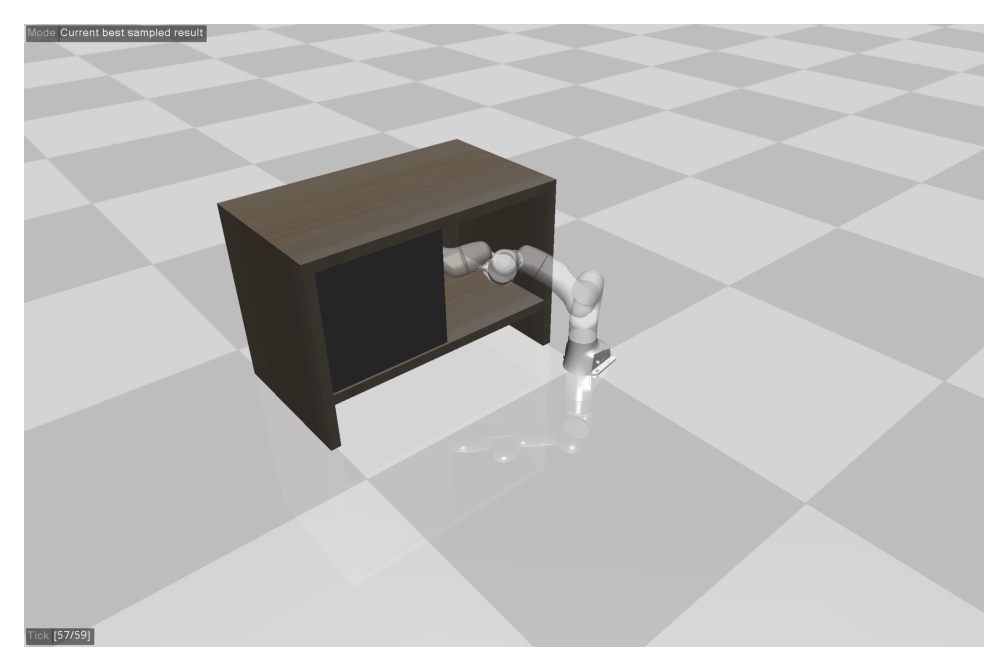

Done.


In [7]:
mode_str = "Current best sampled result"
animate_cabinet_env_traj(
    env,
    mode_str,
    traj_best,
    panda_joints,
    inspire_joints,
    q_pandas,
    q_inspire0,
    p_cylinder_offset0,
)
imshow(env.final_rgb_img)
print ("Done.")